In [1]:
# AI4I 2020 데이터 파일 처리 + 전처리 파이프라인 + 외부 연동 기초

In [2]:
import warnings
warnings.filterwarnings("ignore")

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
from IPython.display import display

In [5]:
import requests
from bs4 import BeautifulSoup

In [6]:
from pathlib import Path
from datetime import datetime
import sqlite3

In [7]:
# 0. 환경 설정
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 160)
pd.set_option("display.float_format", "{:.3f}".format)

plt.rcParams["figure.figsize"] = (8, 4)
plt.rcParams["axes.unicode_minus"] = False

sns.set_theme(style="whitegrid")

In [8]:
# 한글깨짐 해결, 원인:디폴트 영문글꼴==>한글글꼴
import matplotlib.pyplot as plt
import platform
if platform.system() == 'Windows': # W:대문자
    plt.rcParams['font.family'] = 'Malgun Gothic' # M,G:대문자, 중간에 스페이스 한칸
elif platform.system() == 'Darwin': # 맥OS, D:대문자
    plt.rcParams['font.family'] = 'AppleGothic'
else: # 리눅스
    plt.rcParams['font.family'] = 'NanumGothic'
# -(마이너스 기호) 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

In [9]:
# 1. 폴더 구조 준비
# 실무에서는 파일을 구분해서 관리하는 습관이 중요
base_dir = Path(".")
data_dir = base_dir / "data"
output_dir = base_dir / "output"
raw_dir = output_dir / "raw"
clean_dir = output_dir / "clean"
summary_dir = output_dir / "summary"
log_dir = base_dir / "logs"

raw_dir.mkdir(parents=True, exist_ok=True)
clean_dir.mkdir(parents=True, exist_ok=True)
summary_dir.mkdir(parents=True, exist_ok=True)
log_dir.mkdir(parents=True, exist_ok=True)

print("폴더 준비 완료")
print("data_dir   :", data_dir)
print("raw_dir    :", raw_dir)
print("clean_dir  :", clean_dir)
print("summary_dir:", summary_dir)
print("log_dir    :", log_dir)

폴더 준비 완료
data_dir   : data
raw_dir    : output\raw
clean_dir  : output\clean
summary_dir: output\summary
log_dir    : logs


In [10]:
# 2. 데이터 읽기
file_path = data_dir / "ai4i2020.csv"
df = pd.read_csv(file_path)

df.columns = [
    "udi",
    "product_id",
    "type",
    "air_temp_k",
    "process_temp_k",
    "rotational_speed_rpm",
    "torque_nm",
    "tool_wear_min",
    "machine_failure",
    "twf",
    "hdf",
    "pwf",
    "osf",
    "rnf"
]

print("\n원본 데이터 읽기 완료")
print(f"행 수: {df.shape[0]:,}, 열 수: {df.shape[1]:,}")
display(df.head())


원본 데이터 읽기 완료
행 수: 10,000, 열 수: 14


,udi,product_id,type,air_temp_k,process_temp_k,rotational_speed_rpm,torque_nm,tool_wear_min,machine_failure,twf,hdf,pwf,osf,rnf
0,1,M14860,M,298.100,308.600,1551,42.800,0,0,0,0,0,0,0
1,2,L47181,L,298.200,308.700,1408,46.300,3,0,0,0,0,0,0
2,3,L47182,L,298.100,308.500,1498,49.400,5,0,0,0,0,0,0
3,4,L47183,L,298.200,308.600,1433,39.500,7,0,0,0,0,0,0
4,5,L47184,L,298.200,308.700,1408,40.000,9,0,0,0,0,0,0


In [11]:
# 3. 데이터 파이프라인 관점 설명
print("데이터 파이프라인 관점")
print("- 수집: 파일/API/웹/DB에서 데이터 가져오기")
print("- 저장: 원본 보존")
print("- 처리: 정제/변환/파생변수 생성")
print("- 서비스: 보고서, 대시보드, DB 적재, 예측 모델 입력")

print("\n오늘의 실습 흐름")
print("1) 원본 저장")
print("2) 품질 점검")
print("3) 정제")
print("4) 요약표 생성")
print("5) 파일 저장")
print("6) 로그 기록")
print("7) 선택 실습: API/웹/DB 연결")

데이터 파이프라인 관점
- 수집: 파일/API/웹/DB에서 데이터 가져오기
- 저장: 원본 보존
- 처리: 정제/변환/파생변수 생성
- 서비스: 보고서, 대시보드, DB 적재, 예측 모델 입력

오늘의 실습 흐름
1) 원본 저장
2) 품질 점검
3) 정제
4) 요약표 생성
5) 파일 저장
6) 로그 기록
7) 선택 실습: API/웹/DB 연결


In [12]:
# 4. 원본(raw) 저장
# 원본은 되도록 수정하지 않고 보존
run_time = datetime.now().strftime("%Y%m%d_%H%M%S")
raw_save_path = raw_dir / f"ai4i_raw_{run_time}.csv"

df.to_csv(raw_save_path, index=False, encoding="utf-8-sig")
print("\n원본 저장 완료:", raw_save_path)


원본 저장 완료: output\raw\ai4i_raw_20260323_201458.csv


In [13]:
# 5. 품질 점검
# 적재/분석 전에 최소한의 점검을 수행
quality_check = pd.DataFrame({
    "check_item": [
        "row_count",
        "column_count",
        "null_count_total",
        "duplicated_row_count",
        "duplicated_udi_count",
        "invalid_type_count",
        "negative_tool_wear_count",
        "machine_failure_not_binary_count"
    ],
    "value": [
        len(df),
        len(df.columns),
        int(df.isnull().sum().sum()),
        int(df.duplicated().sum()),
        int(df["udi"].duplicated().sum()),
        int((~df["type"].isin(["L", "M", "H"])).sum()),
        int((df["tool_wear_min"] < 0).sum()),
        int((~df["machine_failure"].isin([0, 1])).sum())
    ]
})

print("\n품질 점검 결과")
display(quality_check)

print("\n해석:")
print("- null_count_total: 전체 결측치 개수")
print("- duplicated_row_count: 완전히 동일한 중복 행 개수")
print("- duplicated_udi_count: 식별자 중복 여부")
print("- invalid_type_count: 허용된 제품 등급(L/M/H) 외 값 개수")
print("- machine_failure_not_binary_count: 0/1 외의 값이 있는지 확인")


품질 점검 결과


,check_item,value
0,row_count,10000
1,column_count,14
2,null_count_total,0
3,duplicated_row_count,0
4,duplicated_udi_count,0
5,invalid_type_count,0
6,negative_tool_wear_count,0
7,machine_failure_not_binary_count,0



해석:
- null_count_total: 전체 결측치 개수
- duplicated_row_count: 완전히 동일한 중복 행 개수
- duplicated_udi_count: 식별자 중복 여부
- invalid_type_count: 허용된 제품 등급(L/M/H) 외 값 개수
- machine_failure_not_binary_count: 0/1 외의 값이 있는지 확인


In [14]:
# 6. 전처리용 복사본 만들기
df_clean = df.copy()

In [15]:
# 7. 업무용 전처리 규칙 적용
# 7-1. product_id 앞 글자 추출
df_clean["product_code"] = df_clean["product_id"].str[0]

# 7-2. type과 product_code가 일치하는지 확인
df_clean["type_match"] = np.where(df_clean["type"] == df_clean["product_code"], 1, 0)

# 7-3. 온도 차이
df_clean["temp_diff"] = df_clean["process_temp_k"] - df_clean["air_temp_k"]

# 7-4. 회전수와 토크를 함께 보는 단순 지표
df_clean["power_proxy"] = df_clean["rotational_speed_rpm"] * df_clean["torque_nm"]

# 7-5. 공구 마모 구간화
df_clean["tool_wear_group"] = pd.cut(
    df_clean["tool_wear_min"],
    bins=[-1, 50, 150, 300],
    labels=["low", "mid", "high"]
)

# 7-6. 공구 마모 경고 기준
df_clean["tool_wear_alert"] = np.where(df_clean["tool_wear_min"] >= 200, 1, 0)

# 7-7. 세부 고장 유형 개수
failure_cols = ["twf", "hdf", "pwf", "osf", "rnf"]
df_clean["failure_type_count"] = df_clean[failure_cols].sum(axis=1)

print("\n전처리 후 상위 5행")
display(df_clean.head())

print("\n전처리 설명")
print("- product_code: product_id에서 앞 글자를 추출한 값")
print("- type_match: type과 product_code가 일치하는지 확인")
print("- temp_diff: 공정 온도와 공기 온도 차이")
print("- power_proxy: 회전수와 토크를 함께 본 단순 지표")
print("- tool_wear_group: 공구 마모 시간 구간화")
print("- tool_wear_alert: 공구 마모 경고 기준(200분 이상)")
print("- failure_type_count: 세부 고장 유형 개수 합")


전처리 후 상위 5행


,udi,product_id,type,air_temp_k,process_temp_k,rotational_speed_rpm,torque_nm,tool_wear_min,machine_failure,twf,hdf,pwf,osf,rnf,product_code,type_match,temp_diff,power_proxy,tool_wear_group,tool_wear_alert,failure_type_count
0,1,M14860,M,298.100,308.600,1551,42.800,0,0,0,0,0,0,0,M,1,10.500,66382.800,low,0,0
1,2,L47181,L,298.200,308.700,1408,46.300,3,0,0,0,0,0,0,L,1,10.500,65190.400,low,0,0
2,3,L47182,L,298.100,308.500,1498,49.400,5,0,0,0,0,0,0,L,1,10.400,74001.200,low,0,0
3,4,L47183,L,298.200,308.600,1433,39.500,7,0,0,0,0,0,0,L,1,10.400,56603.500,low,0,0
4,5,L47184,L,298.200,308.700,1408,40.000,9,0,0,0,0,0,0,L,1,10.500,56320.000,low,0,0



전처리 설명
- product_code: product_id에서 앞 글자를 추출한 값
- type_match: type과 product_code가 일치하는지 확인
- temp_diff: 공정 온도와 공기 온도 차이
- power_proxy: 회전수와 토크를 함께 본 단순 지표
- tool_wear_group: 공구 마모 시간 구간화
- tool_wear_alert: 공구 마모 경고 기준(200분 이상)
- failure_type_count: 세부 고장 유형 개수 합


tool_wear_group 분포


,count
tool_wear_group,
mid,4566
high,3038
low,2396



tool_wear_alert 분포


,count
tool_wear_alert,
0,9199
1,801



공구 마모 경고 기준별 요약


,count,avg_tool_wear,avg_temp_diff,avg_power_proxy,failure_rate
tool_wear_alert,,,,,
0,9199,98.937,10.004,59984.450,0.023
1,801,211.476,9.965,59768.433,0.154


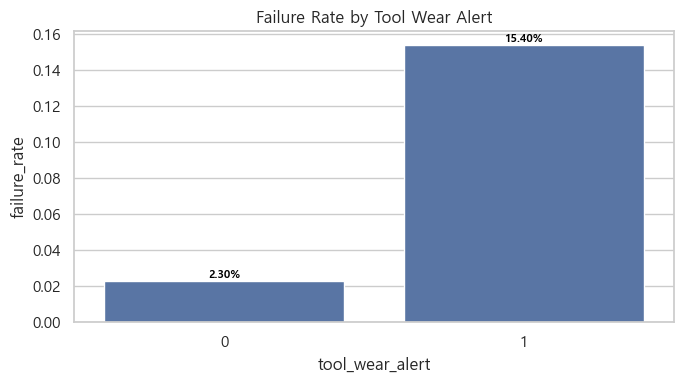


해석:
- 공구 마모가 심한 그룹의 고장률이 더 높은지 탐색할 수 있습니다.
- 이처럼 구간화/경고 기준 생성은 현업 규칙 기반 관리와 연결됩니다.


In [16]:
# 8. 정제 결과 이해
print("tool_wear_group 분포")
display(df_clean["tool_wear_group"].value_counts().to_frame("count"))

print("\ntool_wear_alert 분포")
display(df_clean["tool_wear_alert"].value_counts().to_frame("count"))

summary_alert = df_clean.groupby("tool_wear_alert").agg(
    count=("udi", "count"),
    avg_tool_wear=("tool_wear_min", "mean"),
    avg_temp_diff=("temp_diff", "mean"),
    avg_power_proxy=("power_proxy", "mean"),
    failure_rate=("machine_failure", "mean")
).round(3)

print("\n공구 마모 경고 기준별 요약")
display(summary_alert)

plt.figure(figsize=(7, 4))
ax = sns.barplot(x=summary_alert.index.astype(str), y=summary_alert["failure_rate"])
for i in ax.containers:
    ax.bar_label(i, fmt="{:.2%}", fontsize=8, color="black", fontweight="bold")
plt.title("Failure Rate by Tool Wear Alert")
plt.xlabel("tool_wear_alert")
plt.ylabel("failure_rate")
plt.tight_layout()
plt.show()

print("\n해석:")
print("- 공구 마모가 심한 그룹의 고장률이 더 높은지 탐색할 수 있습니다.")
print("- 이처럼 구간화/경고 기준 생성은 현업 규칙 기반 관리와 연결됩니다.")


제품 type별 요약


,count,avg_air_temp,avg_process_temp,avg_rpm,avg_torque,avg_tool_wear,avg_temp_diff,avg_power_proxy,failure_rate
type,,,,,,,,,
H,1003,299.867,309.926,1538.148,39.838,107.420,10.059,59812.642,0.021
L,6000,300.016,310.012,1539.469,39.997,108.379,9.996,59995.868,0.039
M,2997,300.029,310.019,1537.599,40.017,107.272,9.990,59961.355,0.028


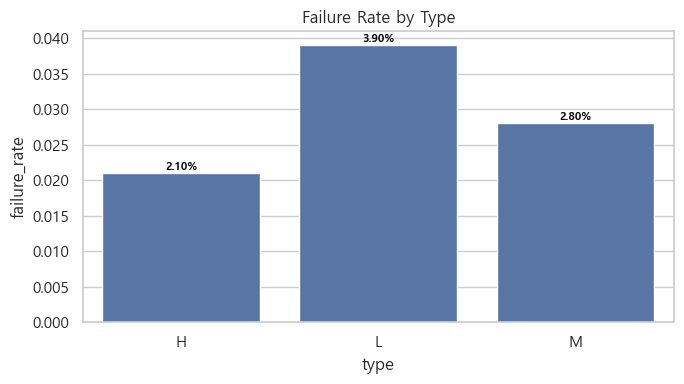

In [17]:
# 9. type별 업무용 요약표 만들기
summary_type = df_clean.groupby("type").agg(
    count=("udi", "count"),
    avg_air_temp=("air_temp_k", "mean"),
    avg_process_temp=("process_temp_k", "mean"),
    avg_rpm=("rotational_speed_rpm", "mean"),
    avg_torque=("torque_nm", "mean"),
    avg_tool_wear=("tool_wear_min", "mean"),
    avg_temp_diff=("temp_diff", "mean"),
    avg_power_proxy=("power_proxy", "mean"),
    failure_rate=("machine_failure", "mean")
).round(3)

print("\n제품 type별 요약")
display(summary_type)

plt.figure(figsize=(7, 4))
ax = sns.barplot(x=summary_type.index, y=summary_type["failure_rate"])
for i in ax.containers:
    ax.bar_label(i, fmt="{:.2%}", fontsize=8, color="black", fontweight="bold")
plt.title("Failure Rate by Type")
plt.tight_layout()
plt.show()


고장 유형별 요약


,failure_type,count,rate_percent
1,hdf,115,1.150
3,osf,98,0.980
2,pwf,95,0.950
0,twf,46,0.460
4,rnf,19,0.190


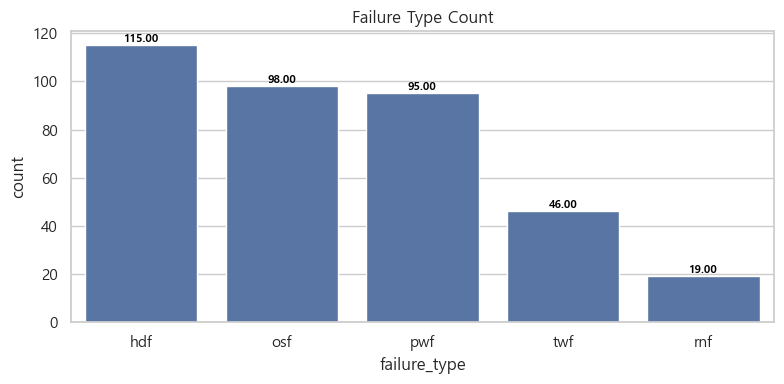


해석:
- machine_failure는 전체 고장 여부이고,
- twf/hdf/pwf/osf/rnf는 세부 고장 원인을 나눠서 보는 컬럼입니다.
- 세부 유형 분포를 보면 어떤 고장 패턴이 더 많은지 파악할 수 있습니다.


In [18]:
# 10. 고장 유형별 업무용 요약표 만들기
failure_summary = pd.DataFrame({
    "failure_type": failure_cols,
    "count": [df_clean[col].sum() for col in failure_cols],
    "rate_percent": [df_clean[col].mean() * 100 for col in failure_cols]
}).sort_values("count", ascending=False)

failure_summary["rate_percent"] = failure_summary["rate_percent"].round(3)

print("\n고장 유형별 요약")
display(failure_summary)

plt.figure(figsize=(8, 4))
ax = sns.barplot(data=failure_summary, x="failure_type", y="count")
for i in ax.containers:
    ax.bar_label(i, fmt="{:.2f}", fontsize=8, color="black", fontweight="bold")
plt.title("Failure Type Count")
plt.tight_layout()
plt.show()

print("\n해석:")
print("- machine_failure는 전체 고장 여부이고,")
print("- twf/hdf/pwf/osf/rnf는 세부 고장 원인을 나눠서 보는 컬럼입니다.")
print("- 세부 유형 분포를 보면 어떤 고장 패턴이 더 많은지 파악할 수 있습니다.")

In [19]:
# 11. 업무 보고용 파일 저장
clean_path = clean_dir / f"ai4i_cleaned_{run_time}.csv"
summary_type_path = summary_dir / f"ai4i_summary_type_{run_time}.csv"
summary_alert_path = summary_dir / f"ai4i_summary_alert_{run_time}.csv"
failure_summary_path = summary_dir / f"ai4i_failure_summary_{run_time}.csv"

df_clean.to_csv(clean_path, index=False, encoding="utf-8-sig")
summary_type.to_csv(summary_type_path, encoding="utf-8-sig")
summary_alert.to_csv(summary_alert_path, encoding="utf-8-sig")
failure_summary.to_csv(failure_summary_path, index=False, encoding="utf-8-sig")

print("\n파일 저장 완료")
print(clean_path)
print(summary_type_path)
print(summary_alert_path)
print(failure_summary_path)


파일 저장 완료
output\clean\ai4i_cleaned_20260323_201458.csv
output\summary\ai4i_summary_type_20260323_201458.csv
output\summary\ai4i_summary_alert_20260323_201458.csv
output\summary\ai4i_failure_summary_20260323_201458.csv


In [20]:
# 12. 처리 로그 남기기
# 나중에 '언제 어떤 파일을 어떤 결과로 처리했는지' 확인 가능
log_df = pd.DataFrame([{
    "run_time": run_time,
    "source_file": str(file_path),
    "raw_file": str(raw_save_path),
    "clean_file": str(clean_path),
    "row_count": len(df_clean),
    "column_count": len(df_clean.columns),
    "null_count_total": int(df_clean.isnull().sum().sum()),
    "type_match_rate": round(df_clean["type_match"].mean(), 4),
    "failure_rate": round(df_clean["machine_failure"].mean(), 4),
    "status": "SUCCESS"
}])

log_path = log_dir / "day2_pipeline_log.csv"

if log_path.exists():
    old_log = pd.read_csv(log_path)
    log_df = pd.concat([old_log, log_df], ignore_index=True)

log_df.to_csv(log_path, index=False, encoding="utf-8-sig")

print("\n로그 저장 완료")
display(log_df.tail())

print("\n로그 해석:")
print("- source_file: 입력 파일")
print("- raw_file: 원본 보존 파일")
print("- clean_file: 전처리 완료 파일")
print("- type_match_rate: 제품 ID와 type 일치 비율")
print("- failure_rate: 전체 고장 비율")
print("- status: 처리 성공 여부")


로그 저장 완료


,run_time,source_file,raw_file,clean_file,row_count,column_count,null_count_total,type_match_rate,failure_rate,status
2,20260321_130050,data\ai4i2020.csv,output\raw\ai4i_raw_20260321_130050.csv,output\clean\ai4i_cleaned_20260321_130050.csv,10000,21,0,1.000,0.034,SUCCESS
3,20260322_204846,data\ai4i2020.csv,output\raw\ai4i_raw_20260322_204846.csv,output\clean\ai4i_cleaned_20260322_204846.csv,10000,21,0,1.000,0.034,SUCCESS
4,20260322_205101,data\ai4i2020.csv,output\raw\ai4i_raw_20260322_205101.csv,output\clean\ai4i_cleaned_20260322_205101.csv,10000,21,0,1.000,0.034,SUCCESS
5,20260323_201230,data\ai4i2020.csv,output\raw\ai4i_raw_20260323_201230.csv,output\clean\ai4i_cleaned_20260323_201230.csv,10000,21,0,1.000,0.034,SUCCESS
6,20260323_201458,data\ai4i2020.csv,output\raw\ai4i_raw_20260323_201458.csv,output\clean\ai4i_cleaned_20260323_201458.csv,10000,21,0,1.000,0.034,SUCCESS



로그 해석:
- source_file: 입력 파일
- raw_file: 원본 보존 파일
- clean_file: 전처리 완료 파일
- type_match_rate: 제품 ID와 type 일치 비율
- failure_rate: 전체 고장 비율
- status: 처리 성공 여부


In [21]:
# 13. 저장한 파일 다시 읽기
# 파이프라인의 결과물을 재활용하는 흐름 연습
loaded_clean = pd.read_csv(clean_path)
loaded_summary_type = pd.read_csv(summary_type_path)

print("\n저장 후 다시 읽은 cleaned 데이터")
display(loaded_clean.head())

print("\n저장 후 다시 읽은 type 요약표")
display(loaded_summary_type.head())

print("\n해석:")
print("- 실무에서는 지금 만든 파일을 다른 팀, 다른 시스템, 다음 작업이 이어서 사용합니다.")
print("- 따라서 저장과 재읽기가 모두 중요합니다.")


저장 후 다시 읽은 cleaned 데이터


,udi,product_id,type,air_temp_k,process_temp_k,rotational_speed_rpm,torque_nm,tool_wear_min,machine_failure,twf,hdf,pwf,osf,rnf,product_code,type_match,temp_diff,power_proxy,tool_wear_group,tool_wear_alert,failure_type_count
0,1,M14860,M,298.100,308.600,1551,42.800,0,0,0,0,0,0,0,M,1,10.500,66382.800,low,0,0
1,2,L47181,L,298.200,308.700,1408,46.300,3,0,0,0,0,0,0,L,1,10.500,65190.400,low,0,0
2,3,L47182,L,298.100,308.500,1498,49.400,5,0,0,0,0,0,0,L,1,10.400,74001.200,low,0,0
3,4,L47183,L,298.200,308.600,1433,39.500,7,0,0,0,0,0,0,L,1,10.400,56603.500,low,0,0
4,5,L47184,L,298.200,308.700,1408,40.000,9,0,0,0,0,0,0,L,1,10.500,56320.000,low,0,0



저장 후 다시 읽은 type 요약표


,type,count,avg_air_temp,avg_process_temp,avg_rpm,avg_torque,avg_tool_wear,avg_temp_diff,avg_power_proxy,failure_rate
0,H,1003,299.867,309.926,1538.148,39.838,107.420,10.059,59812.642,0.021
1,L,6000,300.016,310.012,1539.469,39.997,108.379,9.996,59995.868,0.039
2,M,2997,300.029,310.019,1537.599,40.017,107.272,9.990,59961.355,0.028



해석:
- 실무에서는 지금 만든 파일을 다른 팀, 다른 시스템, 다음 작업이 이어서 사용합니다.
- 따라서 저장과 재읽기가 모두 중요합니다.


In [22]:
# 14. SQLite 연동
# 파일 기반 처리 결과를 DB로도 넣어볼 수 있음
db_path = base_dir / "etl_demo.db"
conn = sqlite3.connect(db_path)

df_clean.to_sql("ai4i_cleaned", conn, if_exists="replace", index=False)
summary_type.reset_index().to_sql("ai4i_summary_type", conn, if_exists="replace", index=False)
summary_alert.reset_index().to_sql("ai4i_summary_alert", conn, if_exists="replace", index=False)

print("\nSQLite 적재 완료:", db_path)

query = """
SELECT
    type,
    count,
    avg_rpm,
    avg_torque,
    failure_rate
FROM ai4i_summary_type
ORDER BY failure_rate DESC
"""

db_result = pd.read_sql_query(query, conn)

print("\nDB에서 다시 조회한 결과")
display(db_result)

conn.close()

print("\n해석:")
print("- 같은 데이터를 CSV로도 저장하고, DB에도 넣을 수 있습니다.")
print("- DB에 적재하면 SQL로 다시 조회하고 다른 시스템과 연결하기 쉬워집니다.")


SQLite 적재 완료: etl_demo.db

DB에서 다시 조회한 결과


,type,count,avg_rpm,avg_torque,failure_rate
0,L,6000,1539.469,39.997,0.039
1,M,2997,1537.599,40.017,0.028
2,H,1003,1538.148,39.838,0.021



해석:
- 같은 데이터를 CSV로도 저장하고, DB에도 넣을 수 있습니다.
- DB에 적재하면 SQL로 다시 조회하고 다른 시스템과 연결하기 쉬워집니다.


In [23]:
# 15. 선택 실습 1: API 호출 예시
# 사내망 제한 시 실패할 수 있으므로 try-except 처리
print("\n선택 실습: API 호출 예시")

api_url = "https://jsonplaceholder.typicode.com/posts"

try:
    response = requests.get(api_url, timeout=5)
    response.raise_for_status()
    api_data = response.json()

    df_api = pd.DataFrame(api_data)

    print("API 호출 성공")
    display(df_api.head())

    api_save_path = raw_dir / f"sample_api_data_{run_time}.csv"
    df_api.to_csv(api_save_path, index=False, encoding="utf-8-sig")
    print("API 데이터 저장:", api_save_path)

except Exception as e:
    print("API 호출 실패:", e)
    print("사내 인터넷 제한 환경이라면 이 구간은 설명용으로만 진행해도 됩니다.")


선택 실습: API 호출 예시
API 호출 성공


,userId,id,title,body
0,1,1,sunt aut facere repellat provident occaecati e...,quia et suscipit\nsuscipit recusandae consequu...
1,1,2,qui est esse,est rerum tempore vitae\nsequi sint nihil repr...
2,1,3,ea molestias quasi exercitationem repellat qui...,et iusto sed quo iure\nvoluptatem occaecati om...
3,1,4,eum et est occaecati,ullam et saepe reiciendis voluptatem adipisci\...
4,1,5,nesciunt quas odio,repudiandae veniam quaerat sunt sed\nalias aut...


API 데이터 저장: output\raw\sample_api_data_20260323_201458.csv


In [24]:
# 16. 선택 실습 2: 웹 페이지 제목 수집 예시
print("\n선택 실습: 웹 페이지 제목 수집 예시")

web_url = "https://example.com"

try:
    response = requests.get(web_url, timeout=5)
    response.raise_for_status()

    soup = BeautifulSoup(response.text, "html.parser")
    page_title = soup.title.text.strip() if soup.title else "제목 없음"

    df_web = pd.DataFrame([{
        "url": web_url,
        "page_title": page_title
    }])

    display(df_web)

except Exception as e:
    print("웹 수집 실패:", e)
    print("사내 인터넷 제한 환경이라면 이 구간은 설명용으로만 진행해도 됩니다.")


선택 실습: 웹 페이지 제목 수집 예시
웹 수집 실패: HTTPSConnectionPool(host='example.com', port=443): Max retries exceeded with url: / (Caused by SSLError(SSLCertVerificationError(1, '[SSL: CERTIFICATE_VERIFY_FAILED] certificate verify failed: unable to get local issuer certificate (_ssl.c:1016)')))
사내 인터넷 제한 환경이라면 이 구간은 설명용으로만 진행해도 됩니다.


In [25]:
# 17. 2일차 마무리 메시지
print("\n" + "=" * 60)
print("2일차 정리")
print("=" * 60)
print("오늘은 데이터를")
print("1) 원본으로 보존하고")
print("2) 정제 규칙을 적용하고")
print("3) 요약표를 만들고")
print("4) 파일로 저장하고")
print("5) 로그를 남기고")
print("6) DB와 외부 연동까지 연결해봤습니다.")

print("\n핵심 메시지:")
print("- 실무에서는 한 번 분석하고 끝나는 코드보다 반복 가능한 처리 흐름이 더 중요합니다.")
print("- raw / clean / summary / log를 나누면 관리와 추적이 쉬워집니다.")
print("- 파일, API, 웹, DB는 서로 다른 것처럼 보여도 결국 같은 파이프라인 안에서 연결됩니다.")


2일차 정리
오늘은 데이터를
1) 원본으로 보존하고
2) 정제 규칙을 적용하고
3) 요약표를 만들고
4) 파일로 저장하고
5) 로그를 남기고
6) DB와 외부 연동까지 연결해봤습니다.

핵심 메시지:
- 실무에서는 한 번 분석하고 끝나는 코드보다 반복 가능한 처리 흐름이 더 중요합니다.
- raw / clean / summary / log를 나누면 관리와 추적이 쉬워집니다.
- 파일, API, 웹, DB는 서로 다른 것처럼 보여도 결국 같은 파이프라인 안에서 연결됩니다.


In [26]:
# end